In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_ollama import ChatOllama
from typing import TypedDict

In [2]:
llm = ChatOllama(model="llama3.2:3b", temperature=0.1)

In [3]:
class BlogState(TypedDict):
    title:str
    outline:str
    content:str

In [4]:
def Create_Outline(state:BlogState) -> BlogState:

    title = state['title']

    prompt = f"Generate a detailed outline for a blog on the topic - {title}"

    outline = llm.invoke(prompt).content
    state['outline'] = outline

    return state

def Create_Blog(state:BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f"Write a detailed Blog on title - {title} using the following outline \n {outline} "
    content=llm.invoke(prompt).content

    state['content'] = content

    return state

In [7]:
graph = StateGraph(BlogState)

graph.add_node('Create_Outline',Create_Outline)
graph.add_node('Create_Blog',Create_Blog)

graph.add_edge(START,"Create_Outline")
graph.add_edge("Create_Outline","Create_Blog")
graph.add_edge("Create_Blog",END)

workflow = graph.compile()

In [8]:
initial_state = {"title":"Rise of Ai over the world and how it effects humans lifes"}

final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of Ai over the world and how it effects humans lifes', 'outline': 'Here is a detailed outline for a blog on the rise of AI and its impact on human lives:\n\n**Title:** "The Rise of AI: How Artificial Intelligence is Revolutionizing Human Life"\n\n**I. Introduction**\n\n* Brief overview of AI and its rapid growth in recent years\n* Importance of understanding the impact of AI on human life\n* Thesis statement: The rise of AI has significant implications for human life, affecting various aspects of our lives, from work to relationships, and requiring us to adapt to a new reality.\n\n**II. The Rise of AI: A Technological Revolution**\n\n* Overview of AI history, from its beginnings in the 1950s to the present day\n* Explanation of different types of AI, including narrow, general, and superintelligence\n* Discussion of key milestones in AI development, such as the creation of AlphaGo and Watson\n\n**III. Impact on Work and Productivity**\n\n* Analysis of how AI is changing 

In [10]:
print(final_state['content'])

The Rise of AI: How Artificial Intelligence is Revolutionizing Human Life

Introduction

Artificial intelligence (AI) has been rapidly growing in recent years, transforming the way we live, work, and interact with each other. From its humble beginnings in the 1950s to the present day, AI has come a long way, becoming an integral part of our daily lives. However, as AI continues to advance at an unprecedented rate, it is essential to understand its impact on human life. This blog post aims to explore the rise of AI and its far-reaching implications for humanity.

The Rise of AI: A Technological Revolution

Artificial intelligence has a rich history that spans over six decades. The term "artificial intelligence" was first coined in 1956 by John McCarthy, and since then, it has evolved into various forms, including narrow, general, and superintelligence. Narrow AI refers to AI systems that are designed to perform specific tasks, such as image recognition or natural language processing. Ge

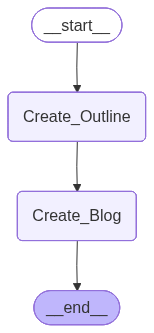

In [11]:
workflow